Primera Entrega

puntos:

2. Para cada base de datos presenta sus dimensiones y las primeras 5 líneas.

3. Identifica y elimina los datos ausentes.

4. Presenta los tipos de datos de cada atributo de cada base de datos.

5. Presenta el resumen estadístico de cada uno de los atributos de cada base de datos.

6. Presenta la distribución de clases de cada base de datos.

7. Presenta la correlación entre atributos de cada base de datos. 

8. Presenta el histograma de los atributos de cada base de datos.

9. Genera la gráfica de densidad para la distribución de los atributos de cada base de datos.

10. Genera la gráfica de cajas y bigotes para la distribución de los atributos de cada base de datos.

11. Genera la matriz de correlación de los atributos para cada una de las bases de datos.

12. Genera la matriz de dispersión de los atributos para cada base de datos.

13. Aplica escalamiento, normalización o estandarización según sea el caso a cada base de datos.

In [ ]:
Directorio de las bases de datos:
\DataSets\MHEALTHDATASET\mHealth_subject1.log

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Dimensiones de la base de datos de MHEALTH

In [14]:
MHEALTHDATASET = pd.read_csv(
    r"DataSets\MHEALTHDATASET\mHealth_subject2.log",
    sep='\t',
    header=None
)

column_names = [
    # Chest sensor
    "chest_acc_x",
    "chest_acc_y",
    "chest_acc_z",
    "ecg_1",
    "ecg_2",

    # Left ankle
    "ankle_acc_x",
    "ankle_acc_y",
    "ankle_acc_z",
    "ankle_gyro_x",
    "ankle_gyro_y",
    "ankle_gyro_z",
    "ankle_mag_x",
    "ankle_mag_y",
    "ankle_mag_z",

    # Right lower arm
    "arm_acc_x",
    "arm_acc_y",
    "arm_acc_z",
    "arm_gyro_x",
    "arm_gyro_y",
    "arm_gyro_z",
    "arm_mag_x",
    "arm_mag_y",
    "arm_mag_z",

    # Label
    "activity_label"
]

pd.set_option('display.max_columns', None)
MHEALTHDATASET.columns = column_names

In [62]:
MHEALTHDATASET.isnull().sum()

chest_acc_x       0
chest_acc_y       0
chest_acc_z       0
ecg_1             0
ecg_2             0
ankle_acc_x       0
ankle_acc_y       0
ankle_acc_z       0
ankle_gyro_x      0
ankle_gyro_y      0
ankle_gyro_z      0
ankle_mag_x       0
ankle_mag_y       0
ankle_mag_z       0
arm_acc_x         0
arm_acc_y         0
arm_acc_z         0
arm_gyro_x        0
arm_gyro_y        0
arm_gyro_z        0
arm_mag_x         0
arm_mag_y         0
arm_mag_z         0
activity_label    0
dtype: int64

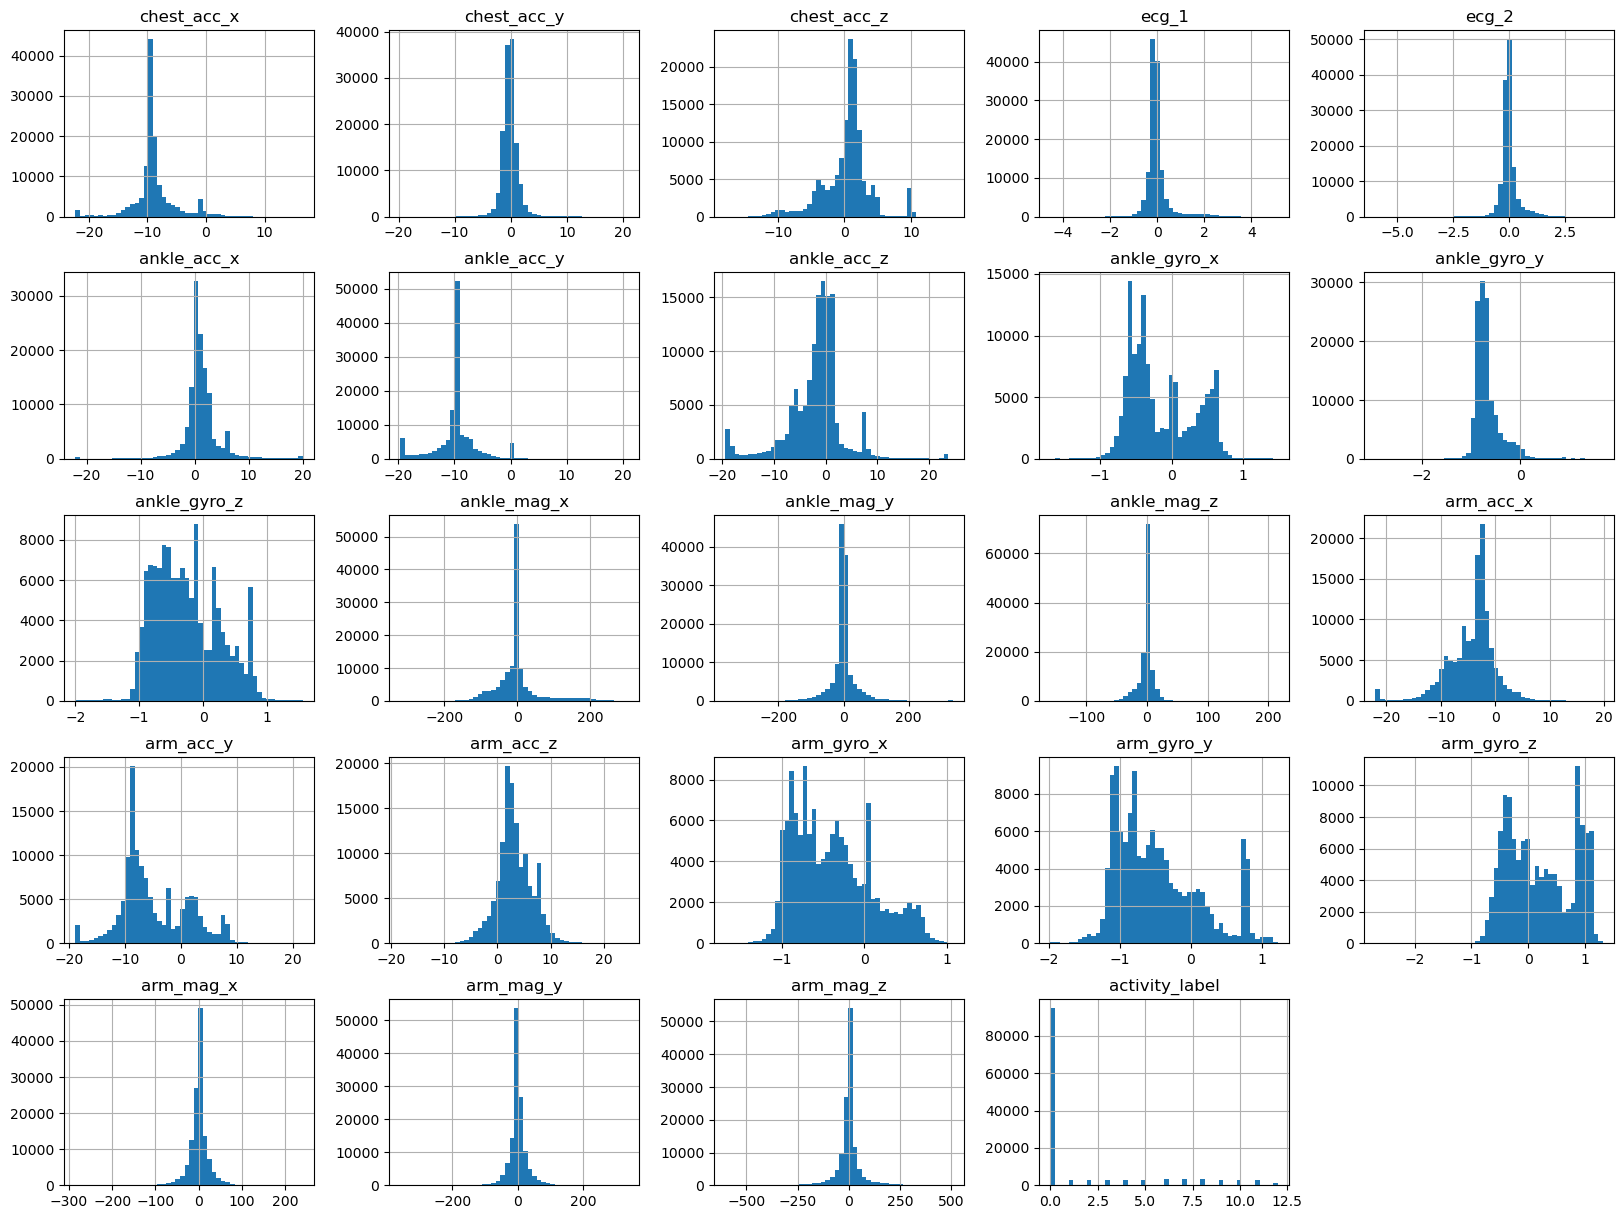

In [11]:
#Punto 2
MHEALTHDATASET.hist(bins=50, figsize=(20,15))
plt.show()


Las dimensiones son 161280 x 24, es decir, tenemos 24 columnas las cuales representan cada sensor:

Column 1: acceleration from the chest sensor (X axis)
Column 2: acceleration from the chest sensor (Y axis)
Column 3: acceleration from the chest sensor (Z axis)
Column 4: electrocardiogram signal (lead 1) 
Column 5: electrocardiogram signal (lead 2)
Column 6: acceleration from the left-ankle sensor (X axis)
Column 7: acceleration from the left-ankle sensor (Y axis)
Column 8: acceleration from the left-ankle sensor (Z axis)
Column 9: gyro from the left-ankle sensor (X axis)
Column 10: gyro from the left-ankle sensor (Y axis)
Column 11: gyro from the left-ankle sensor (Z axis)
Column 13: magnetometer from the left-ankle sensor (X axis)
Column 13: magnetometer from the left-ankle sensor (Y axis)
Column 14: magnetometer from the left-ankle sensor (Z axis)
Column 15: acceleration from the right-lower-arm sensor (X axis)
Column 16: acceleration from the right-lower-arm sensor (Y axis)
Column 17: acceleration from the right-lower-arm sensor (Z axis)
Column 18: gyro from the right-lower-arm sensor (X axis)
Column 19: gyro from the right-lower-arm sensor (Y axis)
Column 20: gyro from the right-lower-arm sensor (Z axis)
Column 21: magnetometer from the right-lower-arm sensor (X axis)
Column 22: magnetometer from the right-lower-arm sensor (Y axis)
Column 23: magnetometer from the right-lower-arm sensor (Z axis)
Column 24: Label (0 for the null class)
%matplotlib inline   # only in a Jupyter notebook
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(20,15))
plt.show()

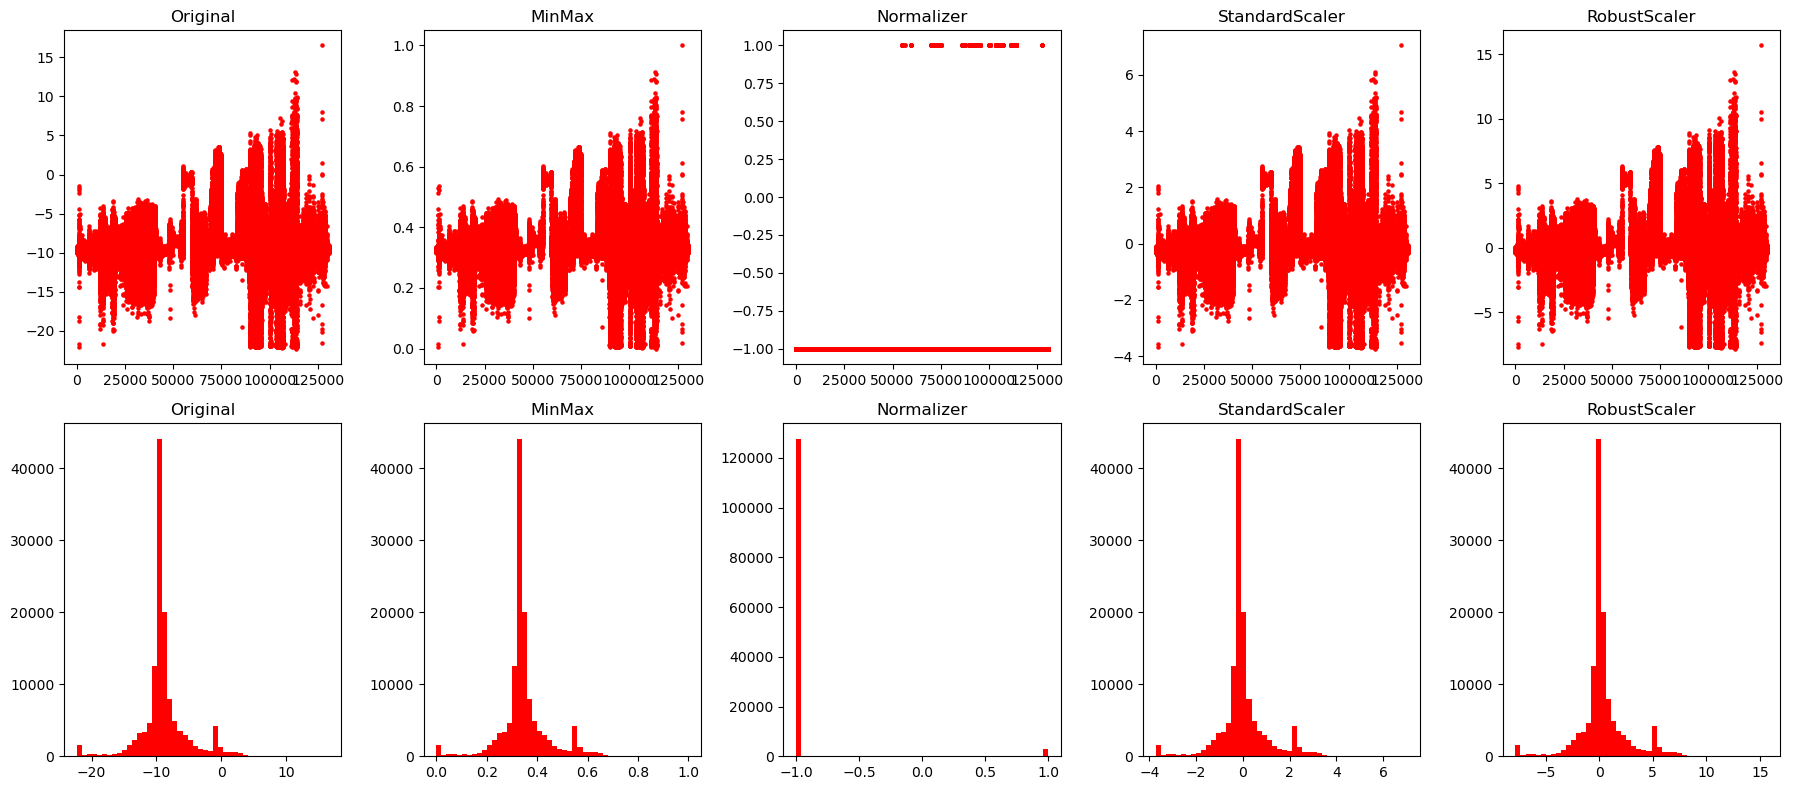

In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import Normalizer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

# ============================
# Selecciona columna a analizar
# ============================

feature_name = "chest_acc_x"
X = MHEALTHDATASET[[feature_name]].values  # debe ser 2D

# ============================
# Aplicar transformaciones
# ============================

minmax = MinMaxScaler().fit_transform(X)
normalizer = Normalizer(norm='l2').fit_transform(X)
standard = StandardScaler().fit_transform(X)
robust = RobustScaler().fit_transform(X)

# ============================
# Graficar comparación
# ============================

fig, axes = plt.subplots(2, 5, figsize=(18, 8))

# ===== Fila 1: Scatter =====

axes[0,0].scatter(range(len(X)), X, color='red', s=5)
axes[0,0].set_title("Original")

axes[0,1].scatter(range(len(minmax)), minmax, color='red', s=5)
axes[0,1].set_title("MinMax")

axes[0,2].scatter(range(len(normalizer)), normalizer, color='red', s=5)
axes[0,2].set_title("Normalizer")

axes[0,3].scatter(range(len(standard)), standard, color='red', s=5)
axes[0,3].set_title("StandardScaler")

axes[0,4].scatter(range(len(robust)), robust, color='red', s=5)
axes[0,4].set_title("RobustScaler")

# ===== Fila 2: Histogramas =====

axes[1,0].hist(X, bins=50, color='red')
axes[1,0].set_title("Original")

axes[1,1].hist(minmax, bins=50, color='red')
axes[1,1].set_title("MinMax")

axes[1,2].hist(normalizer, bins=50, color='red')
axes[1,2].set_title("Normalizer")

axes[1,3].hist(standard, bins=50, color='red')
axes[1,3].set_title("StandardScaler")

axes[1,4].hist(robust, bins=50, color='red')
axes[1,4].set_title("RobustScaler")

plt.tight_layout()
plt.show()


<Axes: >

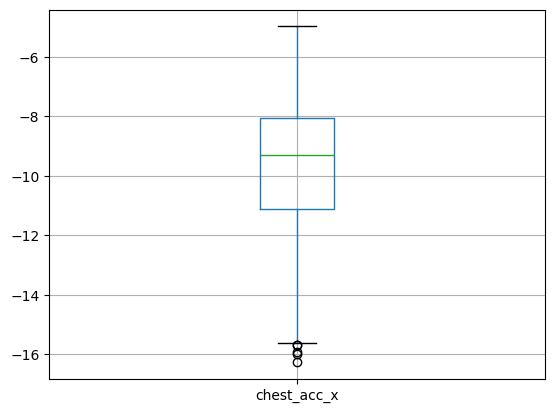

In [61]:
import numpy as np
import matplotlib.pyplot as plt

feature = "chest_acc_x"

# Filtrar caminar (ajusta el número si es necesario)
walking_data = MHEALTHDATASET[MHEALTHDATASET["activity_label"] == 4]
walking_data.boxplot(feature)



In [47]:
#Punto 2
MHEALTHDATASET.describe()

,chest_acc_x,chest_acc_y,chest_acc_z,ecg_1,ecg_2,ankle_acc_x,ankle_acc_y,ankle_acc_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,arm_acc_x,arm_acc_y,arm_acc_z,arm_gyro_x,arm_gyro_y,arm_gyro_z,arm_mag_x,arm_mag_y,arm_mag_z,activity_label
count,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000
mean,-8.858501,-0.187425,0.317355,-0.005755,0.008773,1.203538,-9.673908,-1.947817,-0.145236,-0.664777,-0.253973,-0.030279,-0.300455,-1.447027,-4.248543,-4.827263,3.290395,-0.384279,-0.472784,0.206604,0.020797,1.029566,-0.040666,1.687395
std,3.601440,1.432580,3.519939,0.486367,0.365845,3.340788,3.987678,5.387654,0.455282,0.289222,0.511838,59.939590,42.458931,11.186323,4.448131,5.972981,3.366704,0.473945,0.593786,0.573712,22.465271,29.653227,66.662952,3.238466
min,-22.295000,-19.659000,-17.906000,-4.533800,-5.965500,-22.074000,-19.590000,-19.363000,-1.692000,-2.949300,-1.998000,-319.980000,-362.990000,-159.110000,-22.014000,-18.867000,-18.222000,-1.684300,-1.975400,-2.689700,-284.870000,-358.480000,-601.630000,0.000000
25%,-9.870800,-0.890940,-1.008000,-0.192570,-0.142330,0.012841,-10.299000,-4.063900,-0.521340,-0.827390,-0.660120,-22.661000,-7.955300,-2.967700,-6.452700,-8.919300,1.434100,-0.774510,-0.946610,-0.318970,-7.810200,-8.397800,-14.314000,0.000000
50%,-9.398500,-0.212560,0.881130,-0.087912,-0.033490,0.787790,-9.685900,-1.115100,-0.315400,-0.733580,-0.316310,-0.180500,0.363190,-0.162360,-3.231800,-6.739000,2.901600,-0.449020,-0.601640,0.133620,0.183140,0.329140,-0.359150,0.000000
75%,-8.219300,0.419610,1.852200,0.046049,0.096285,2.183400,-8.857700,0.690660,0.257880,-0.602250,0.161100,3.317800,4.547800,2.211000,-2.004800,0.202710,5.397400,-0.054902,-0.119100,0.846980,7.727000,9.471700,13.170000,1.000000
max,16.526000,20.825000,16.283000,5.124000,4.198800,20.024000,20.842000,24.544000,1.484200,1.677300,1.558000,302.060000,335.780000,215.530000,19.706000,21.827000,24.524000,1.074500,1.225900,1.310300,240.440000,336.220000,506.320000,12.000000


En el readme se nos indica "All sensing modalities are recorded at a sampling rate of 50 Hz", por lo que hay 50 registros por segundo, eso quiere decir que si dividimos 161280/50, podemos decir que la grabacion dura un aproximado de 3,225.6 segundos, esto son 53.76 minutos

In [33]:
#Punto 3
#No existen datos ausentes para eliminar

In [16]:
#Punto 4
count_class = MHEALTHDATASET.groupby('activity_label').size() 
print(count_class) 


activity_label
0     95029
1      3072
2      3072
3      3072
4      3072
5      3072
6      3174
7      3328
8      3430
9      3072
10     3072
11     3072
12     1024
dtype: int64


A excepcion de el ultimo atributo activity label el cual es entero, los demás son flotantes

In [21]:
MHEALTHDATASET.describe()

,chest_acc_x,chest_acc_y,chest_acc_z,ecg_1,ecg_2,ankle_acc_x,ankle_acc_y,ankle_acc_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,arm_acc_x,arm_acc_y,arm_acc_z,arm_gyro_x,arm_gyro_y,arm_gyro_z,arm_mag_x,arm_mag_y,arm_mag_z,activity_label
count,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000,130561.000000
mean,-8.858501,-0.187425,0.317355,-0.005755,0.008773,1.203538,-9.673908,-1.947817,-0.145236,-0.664777,-0.253973,-0.030279,-0.300455,-1.447027,-4.248543,-4.827263,3.290395,-0.384279,-0.472784,0.206604,0.020797,1.029566,-0.040666,1.687395
std,3.601440,1.432580,3.519939,0.486367,0.365845,3.340788,3.987678,5.387654,0.455282,0.289222,0.511838,59.939590,42.458931,11.186323,4.448131,5.972981,3.366704,0.473945,0.593786,0.573712,22.465271,29.653227,66.662952,3.238466
min,-22.295000,-19.659000,-17.906000,-4.533800,-5.965500,-22.074000,-19.590000,-19.363000,-1.692000,-2.949300,-1.998000,-319.980000,-362.990000,-159.110000,-22.014000,-18.867000,-18.222000,-1.684300,-1.975400,-2.689700,-284.870000,-358.480000,-601.630000,0.000000
25%,-9.870800,-0.890940,-1.008000,-0.192570,-0.142330,0.012841,-10.299000,-4.063900,-0.521340,-0.827390,-0.660120,-22.661000,-7.955300,-2.967700,-6.452700,-8.919300,1.434100,-0.774510,-0.946610,-0.318970,-7.810200,-8.397800,-14.314000,0.000000
50%,-9.398500,-0.212560,0.881130,-0.087912,-0.033490,0.787790,-9.685900,-1.115100,-0.315400,-0.733580,-0.316310,-0.180500,0.363190,-0.162360,-3.231800,-6.739000,2.901600,-0.449020,-0.601640,0.133620,0.183140,0.329140,-0.359150,0.000000
75%,-8.219300,0.419610,1.852200,0.046049,0.096285,2.183400,-8.857700,0.690660,0.257880,-0.602250,0.161100,3.317800,4.547800,2.211000,-2.004800,0.202710,5.397400,-0.054902,-0.119100,0.846980,7.727000,9.471700,13.170000,1.000000
max,16.526000,20.825000,16.283000,5.124000,4.198800,20.024000,20.842000,24.544000,1.484200,1.677300,1.558000,302.060000,335.780000,215.530000,19.706000,21.827000,24.524000,1.074500,1.225900,1.310300,240.440000,336.220000,506.320000,12.000000


In [22]:
from sklearn import preprocessing

In [23]:
#Punto 5
array = MHEALTHDATASET.values
data_scaler = preprocessing.MinMaxScaler(feature_range=(0,1)) 
data_rescaled = data_scaler.fit_transform(array)

In [26]:
#Punto 6

print ("\nScaled data:\n", data_rescaled[0:1]) 


Scaled data:
 [[0.32019783 0.492975   0.57316681 0.44256974 0.57249196 0.53621668
  0.24539968 0.47565536 0.38200995 0.52189297 0.71214286 0.51441832
  0.51999496 0.42392046 0.41632071 0.26087875 0.4712207  0.25515079
  0.48621185 0.71984    0.5436769  0.5175732  0.54268946 0.        ]]


In [28]:
from sklearn.preprocessing import Normalizer 
Data_normalizer = Normalizer(norm='l1').fit(array) 
Data_normalized = Data_normalizer.transform(array) 

In [42]:
print ("\nScaled data:\n", Data_normalized[0:1]) 



Scaled data:
 [[-2.20515732e-01  6.67497898e-03  3.77786821e-02 -5.80204552e-03
  -3.27534467e-03  1.11693009e-02 -2.16120887e-01  3.40142264e-02
  -1.07000852e-02 -1.19530409e-02  1.19456640e-02  1.96120539e-04
   8.20132715e-03 -6.53727680e-03 -1.03837726e-01 -1.84440444e-01
   4.29380429e-02 -2.19158829e-02 -9.36397168e-03  4.23970701e-03
   1.62942362e-02  2.41001167e-02 -7.98516155e-03  0.00000000e+00]]


In [39]:
np.abs(Data_normalized[0])

array([2.20515732e-01, 6.67497898e-03, 3.77786821e-02, 5.80204552e-03,
       3.27534467e-03, 1.11693009e-02, 2.16120887e-01, 3.40142264e-02,
       1.07000852e-02, 1.19530409e-02, 1.19456640e-02, 1.96120539e-04,
       8.20132715e-03, 6.53727680e-03, 1.03837726e-01, 1.84440444e-01,
       4.29380429e-02, 2.19158829e-02, 9.36397168e-03, 4.23970701e-03,
       1.62942362e-02, 2.41001167e-02, 7.98516155e-03, 0.00000000e+00])

In [41]:
#Punto 7
MHEALTHDATASETsample.corr()

,chest_acc_x,chest_acc_y,chest_acc_z,ecg_1,ecg_2,ankle_acc_x,ankle_acc_y,ankle_acc_z,ankle_gyro_x,ankle_gyro_y,ankle_gyro_z,ankle_mag_x,ankle_mag_y,ankle_mag_z,arm_acc_x,arm_acc_y,arm_acc_z,arm_gyro_x,arm_gyro_y,arm_gyro_z,arm_mag_x,arm_mag_y,arm_mag_z,activity_label
chest_acc_x,1.000000,-0.116616,0.311093,0.746340,0.700658,-0.192119,0.117354,-0.062157,-0.042456,-0.508992,-0.114801,0.421453,-0.226329,0.382223,0.660145,-0.069893,0.510121,0.472834,-0.472834,0.472834,-0.617500,-0.172169,0.215921,NaN
chest_acc_y,-0.116616,1.000000,0.000049,-0.308843,-0.394132,0.024145,0.089988,0.380182,0.683676,-0.571135,0.666985,-0.836107,-0.031276,-0.825751,-0.055791,0.859813,0.393411,-0.828133,0.828133,-0.828133,-0.316269,-0.578930,0.078909,NaN
chest_acc_z,0.311093,0.000049,1.000000,-0.139328,-0.235546,0.846242,-0.107830,0.740129,0.525170,-0.316650,0.528801,0.316367,-0.184632,0.490291,0.523925,0.347074,0.230581,-0.221035,0.221035,-0.221035,0.437696,0.498243,0.410621,NaN
ecg_1,0.746340,-0.308843,-0.139328,1.000000,0.989315,-0.436635,0.429382,-0.642016,-0.436982,-0.333718,-0.520492,0.263034,-0.046360,0.181085,0.036949,-0.487018,-0.053891,0.585839,-0.585839,0.585839,-0.628703,0.015259,0.061277,NaN
ecg_2,0.700658,-0.394132,-0.235546,0.989315,1.000000,-0.520376,0.412913,-0.720579,-0.523549,-0.236518,-0.601592,0.307018,-0.054929,0.214980,0.019365,-0.587186,-0.097821,0.677652,-0.677652,0.677652,-0.623619,-0.002214,0.029995,NaN
ankle_acc_x,-0.192119,0.024145,0.846242,-0.436635,-0.520376,1.000000,-0.217271,0.742798,0.425801,0.002226,0.463648,0.135720,0.120643,0.287846,0.067542,0.375191,-0.066184,-0.480286,0.480286,-0.480286,0.779815,0.694186,0.157558,NaN
ankle_acc_y,0.117354,0.089988,-0.107830,0.429382,0.412913,-0.217271,1.000000,-0.533719,0.288597,-0.649729,0.226475,-0.432484,-0.658332,-0.230291,-0.243312,-0.330039,-0.566790,0.036146,-0.036146,0.036146,-0.271283,0.054416,0.732091,NaN
ankle_acc_z,-0.062157,0.380182,0.740129,-0.642016,-0.720579,0.742798,-0.533719,1.000000,0.607908,-0.075807,0.651295,0.034769,0.073719,0.107193,0.465509,0.767993,0.540115,-0.568337,0.568337,-0.568337,0.438683,0.073715,0.040606,NaN
ankle_gyro_x,-0.042456,0.683676,0.525170,-0.436982,-0.523549,0.425801,0.288597,0.607908,1.000000,-0.689667,0.995226,-0.530277,-0.564938,-0.291517,0.309260,0.659624,0.201041,-0.665982,0.665982,-0.665982,0.088374,-0.164419,0.673839,NaN
ankle_gyro_y,-0.508992,-0.571135,-0.316650,-0.333718,-0.236518,0.002226,-0.649729,-0.075807,-0.689667,1.000000,-0.615702,0.461087,0.584781,0.304684,-0.281852,-0.353850,-0.192040,0.287231,-0.287231,0.287231,0.499566,0.279673,-0.689569,NaN


array([[<Axes: title={'center': 'chest_acc_x'}>,
        <Axes: title={'center': 'chest_acc_y'}>,
        <Axes: title={'center': 'chest_acc_z'}>,
        <Axes: title={'center': 'ecg_1'}>,
        <Axes: title={'center': 'ecg_2'}>],
       [<Axes: title={'center': 'ankle_acc_x'}>,
        <Axes: title={'center': 'ankle_acc_y'}>,
        <Axes: title={'center': 'ankle_acc_z'}>,
        <Axes: title={'center': 'ankle_gyro_x'}>,
        <Axes: title={'center': 'ankle_gyro_y'}>],
       [<Axes: title={'center': 'ankle_gyro_z'}>,
        <Axes: title={'center': 'ankle_mag_x'}>,
        <Axes: title={'center': 'ankle_mag_y'}>,
        <Axes: title={'center': 'ankle_mag_z'}>,
        <Axes: title={'center': 'arm_acc_x'}>],
       [<Axes: title={'center': 'arm_acc_y'}>,
        <Axes: title={'center': 'arm_acc_z'}>,
        <Axes: title={'center': 'arm_gyro_x'}>,
        <Axes: title={'center': 'arm_gyro_y'}>,
        <Axes: title={'center': 'arm_gyro_z'}>],
       [<Axes: title={'center': 'a

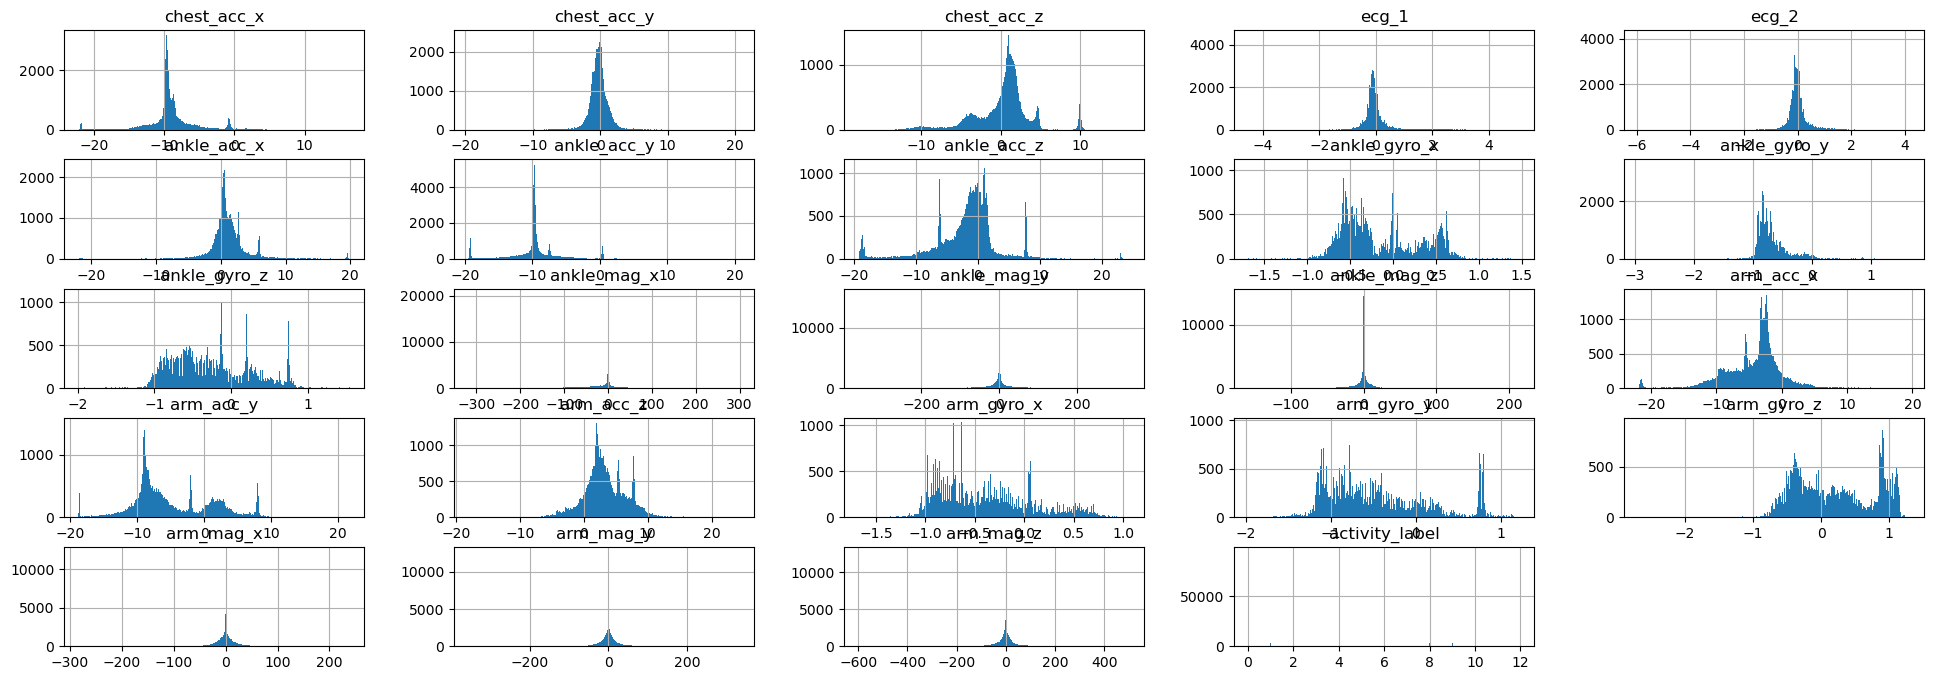

In [58]:
#Punto 8

MHEALTHDATASET.hist(bins=1000, figsize=(24,8))



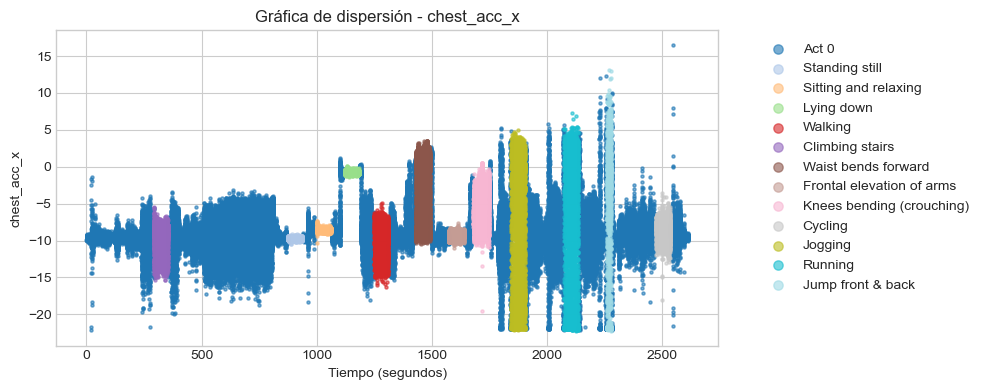

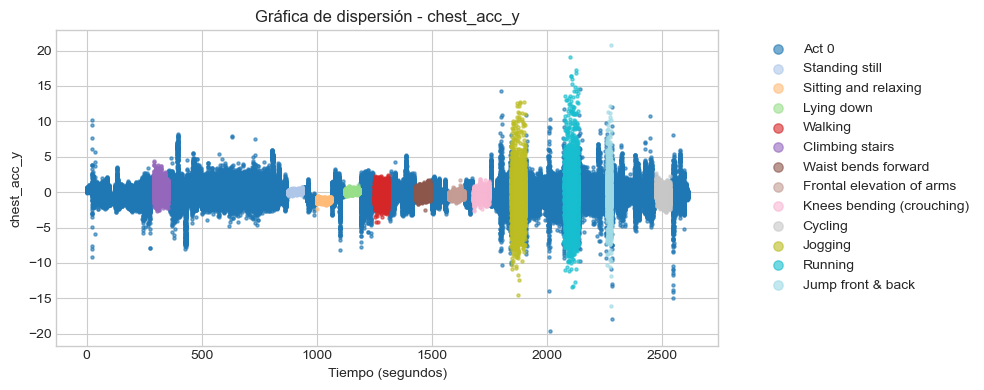

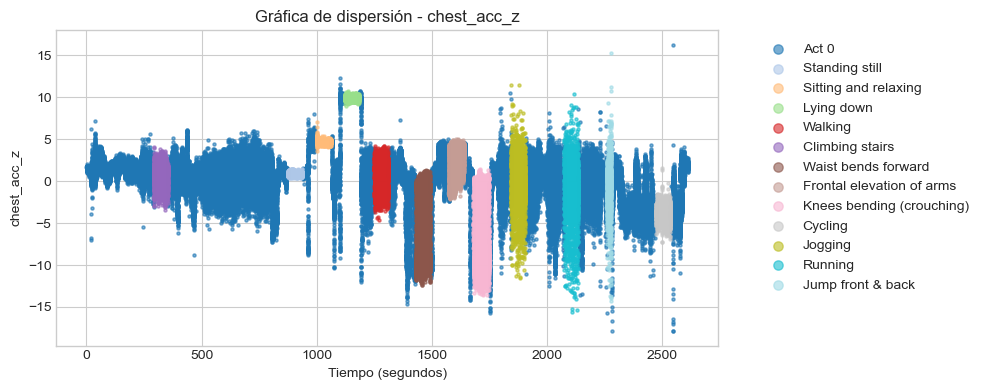

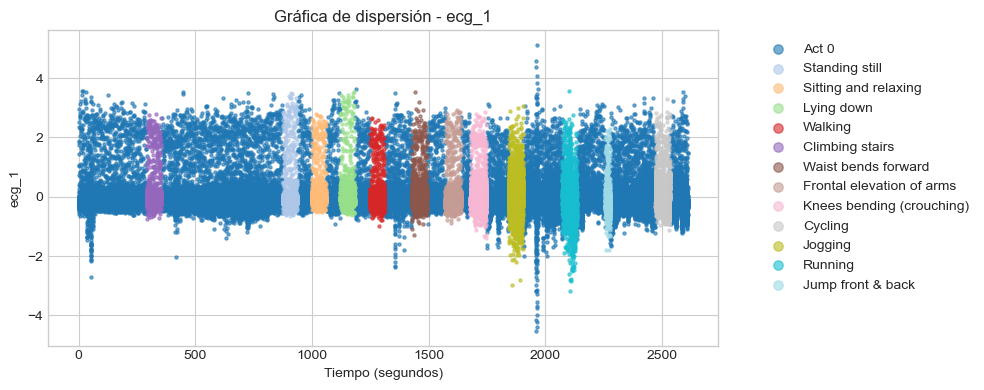

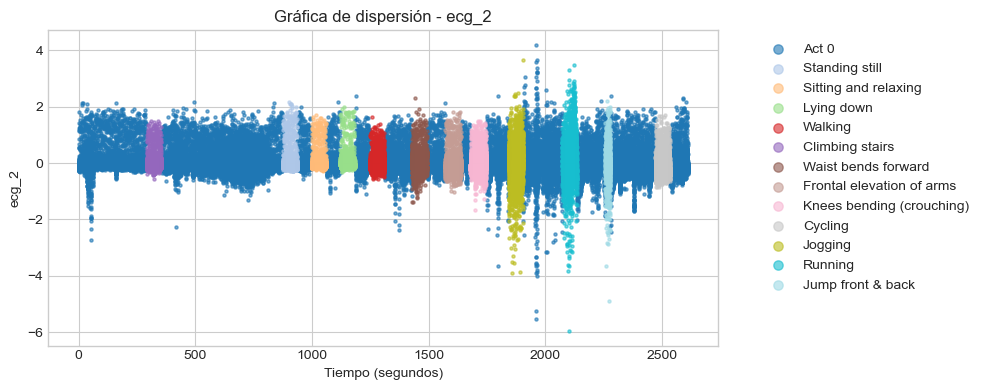

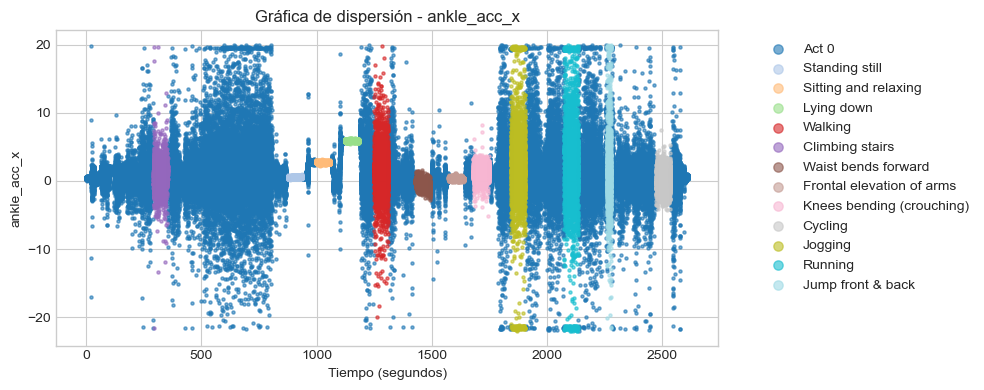

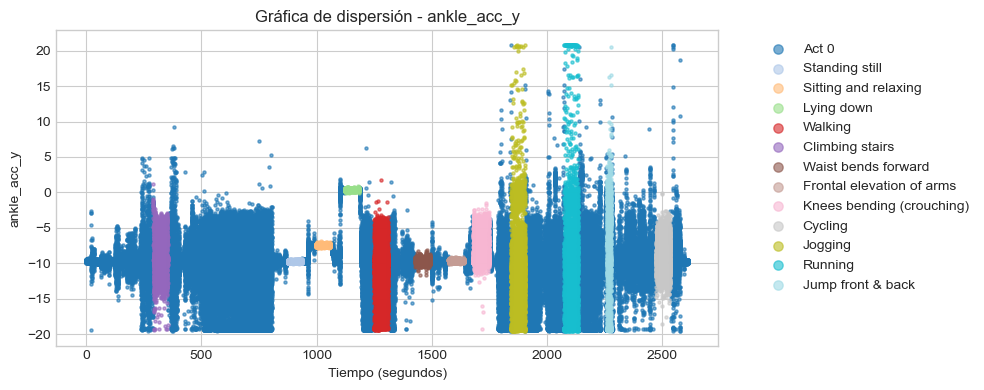

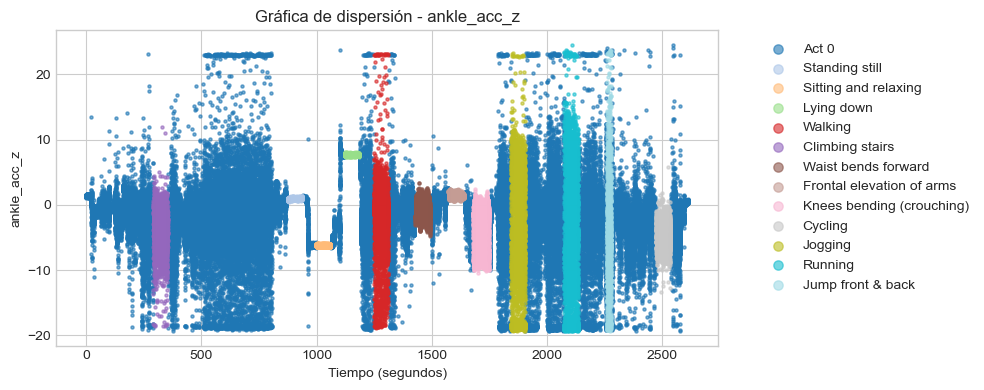

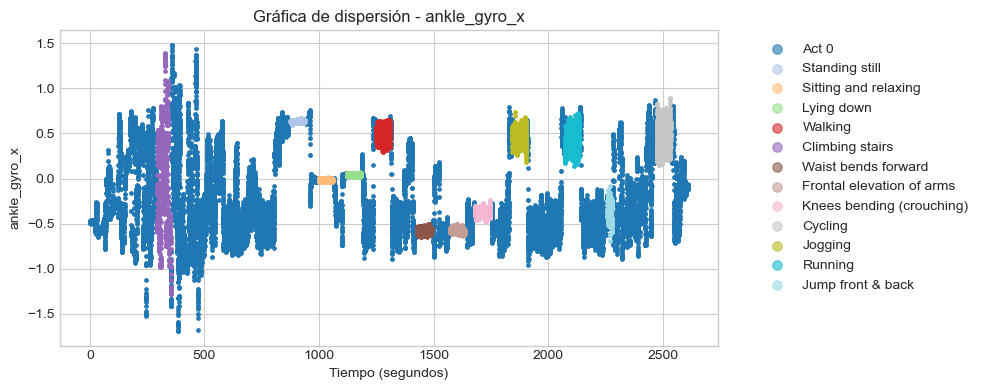

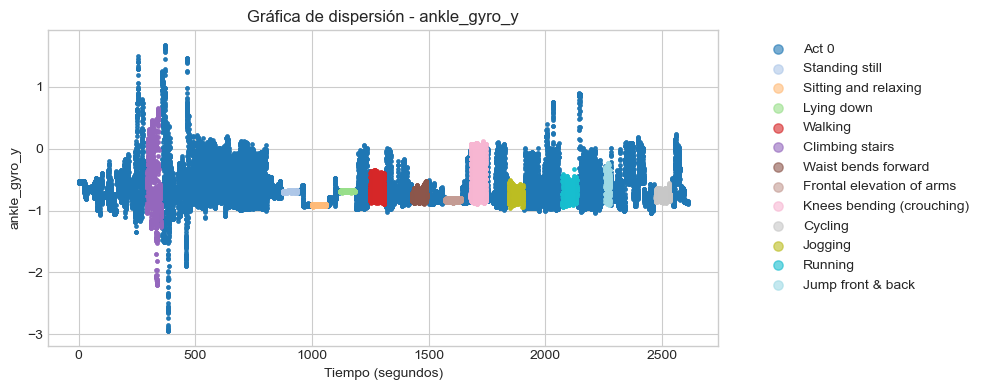

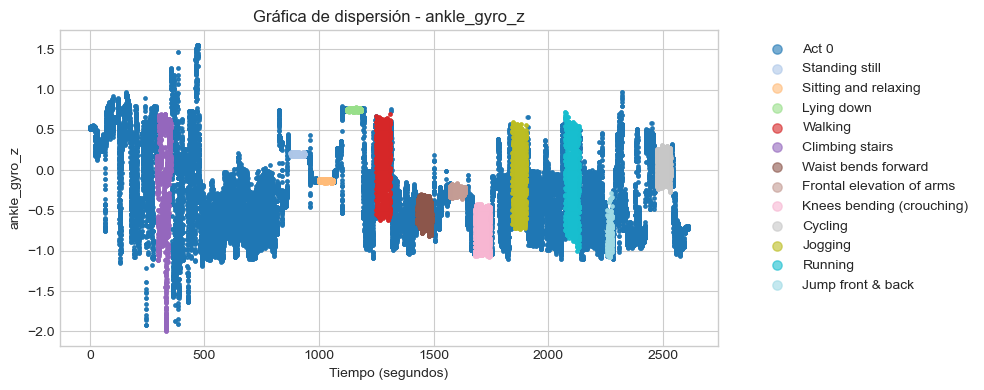

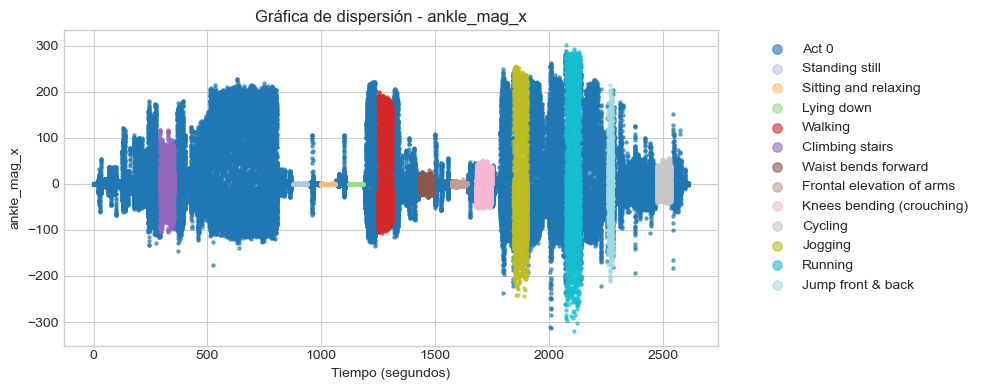

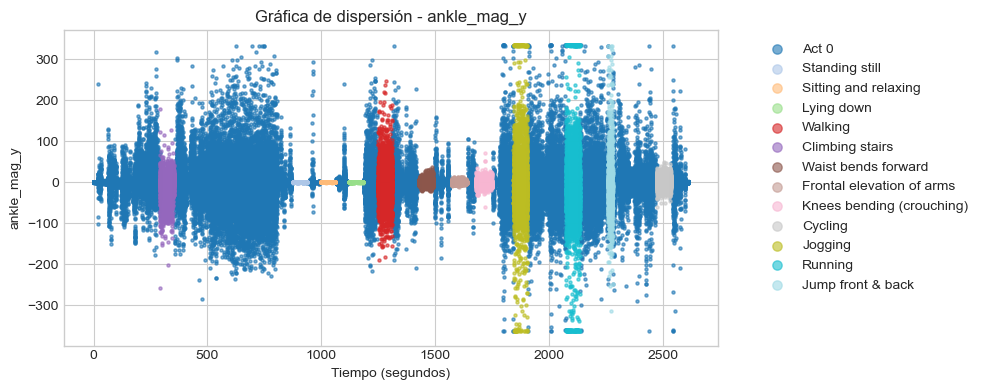

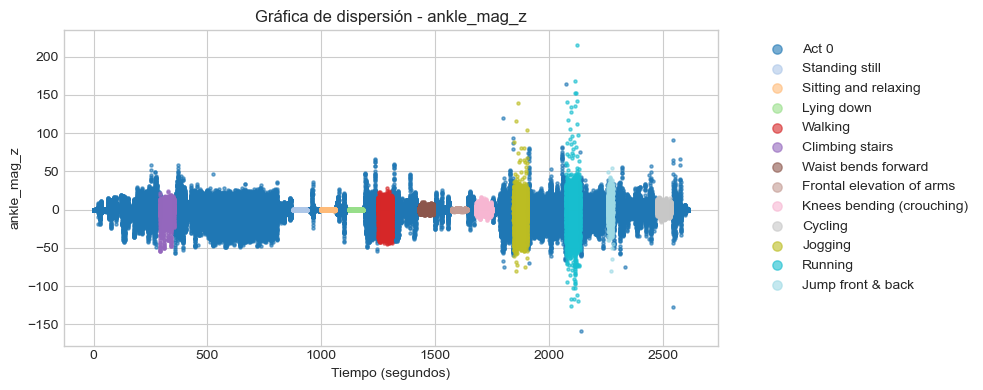

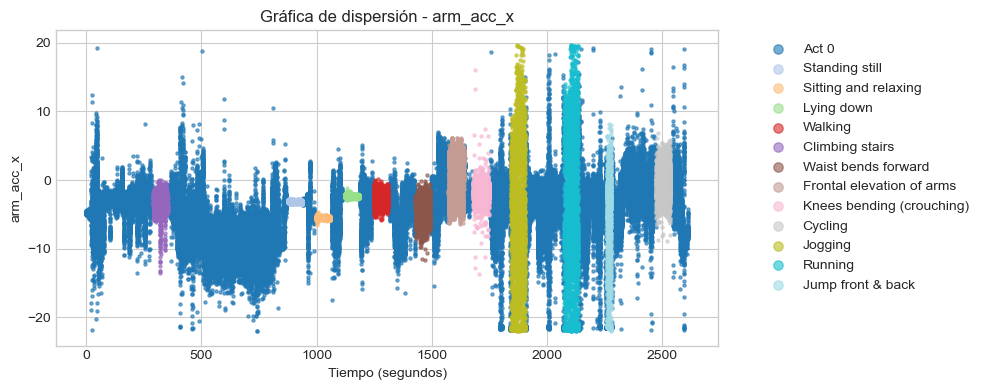

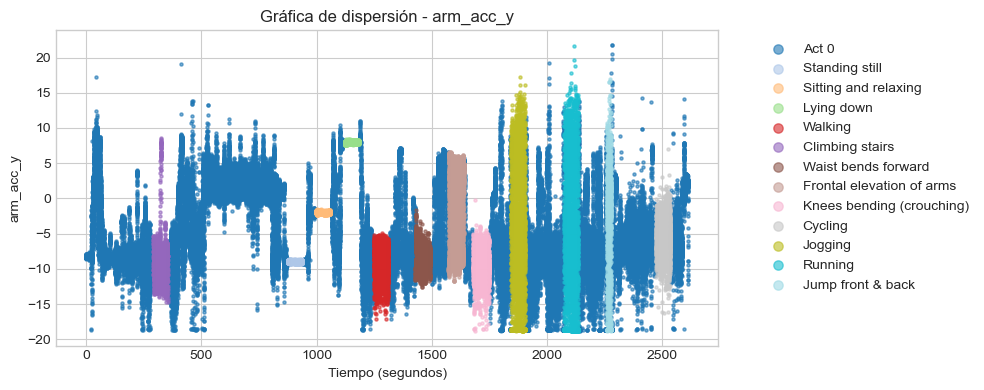

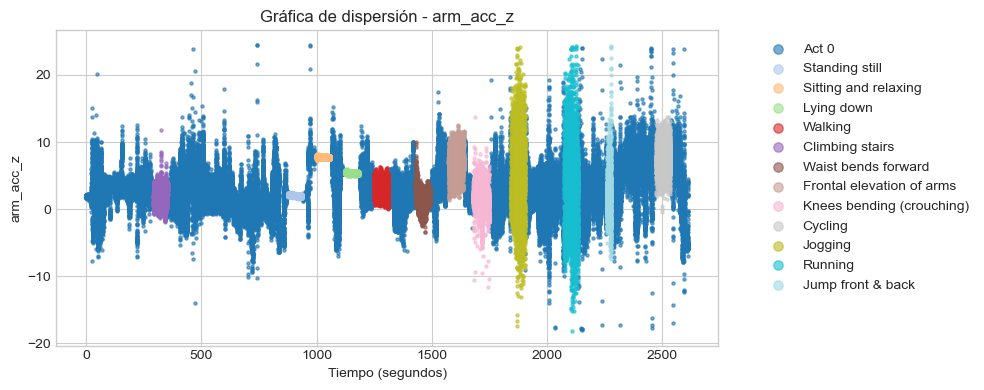

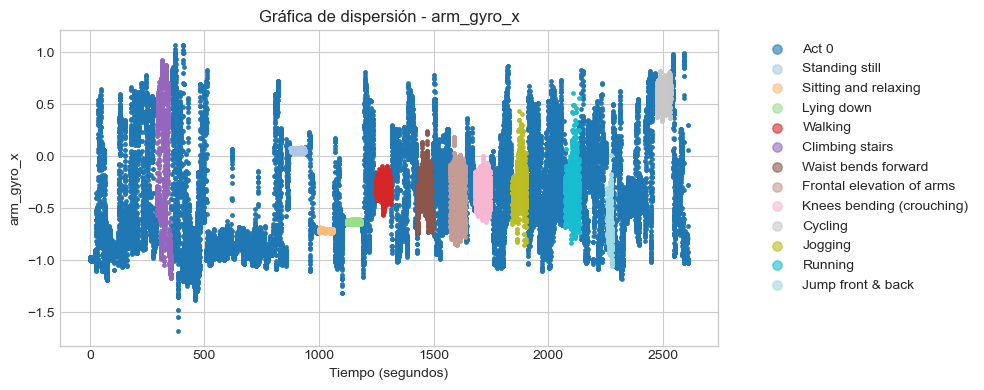

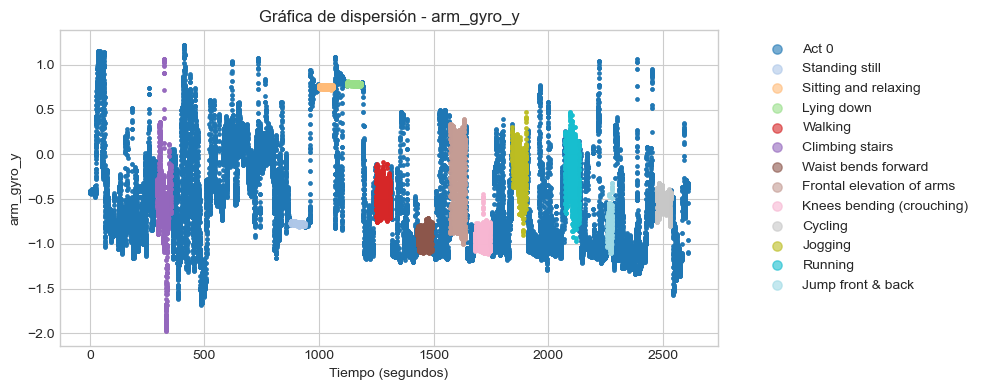

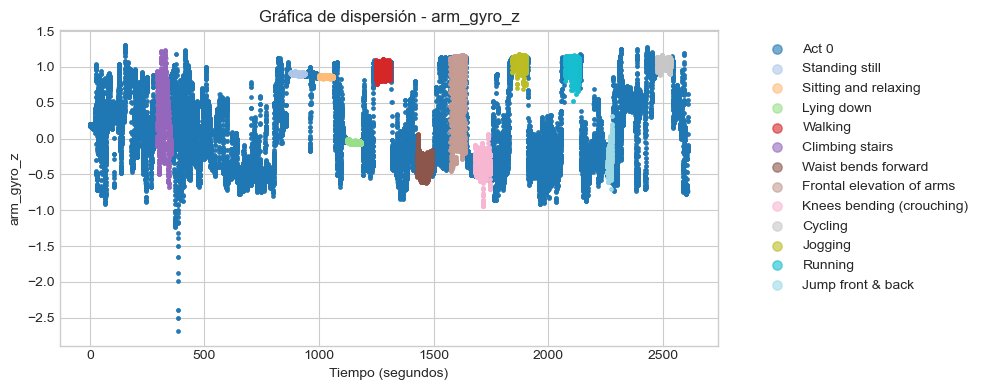

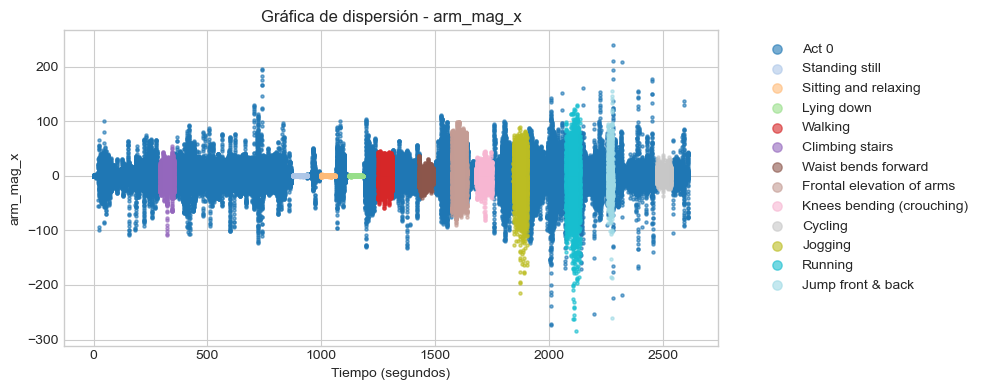

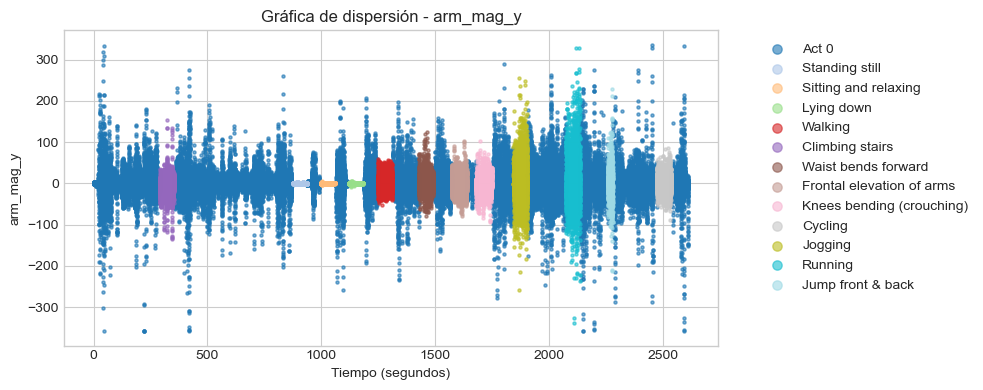

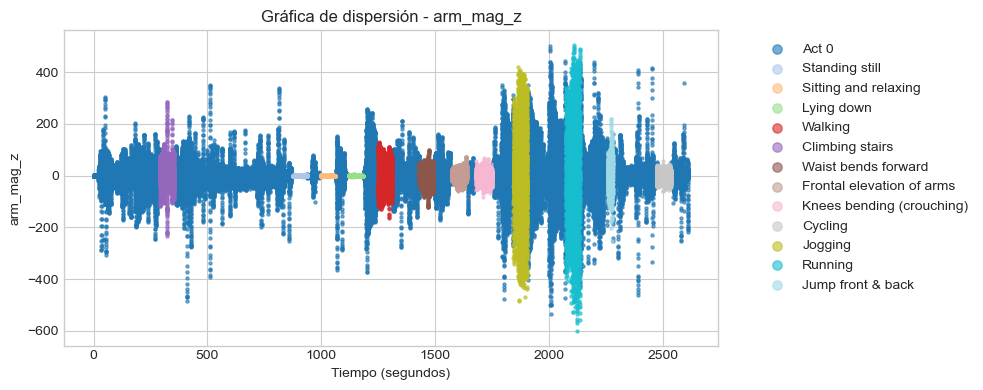

In [8]:
import matplotlib.pyplot as plt
import numpy as np

if "MHEALTHDATASET" in globals():
    
    # Diccionario de etiquetas
    activity_names = {
        1: "Standing still",
        2: "Sitting and relaxing",
        3: "Lying down",
        4: "Walking",
        5: "Climbing stairs",
        6: "Waist bends forward",
        7: "Frontal elevation of arms",
        8: "Knees bending (crouching)",
        9: "Cycling",
        10: "Jogging",
        11: "Running",
        12: "Jump front & back"
    }
    
    # Convertir índice a tiempo en segundos (50 Hz)
    time_seconds = MHEALTHDATASET.index / 50.0
    
    # Obtener actividades únicas ordenadas
    activities = sorted(MHEALTHDATASET["activity_label"].unique())
    
    # Mapa de colores
    cmap = plt.cm.get_cmap("tab20", len(activities))
    
    for column in MHEALTHDATASET.columns:
        
        if column == "activity_label":
            continue
        
        plt.figure(figsize=(10,4))
        
        for i, activity in enumerate(activities):
            
            subset = MHEALTHDATASET[MHEALTHDATASET["activity_label"] == activity]
            subset_time = subset.index / 50.0
            
            plt.scatter(
                subset_time,
                subset[column],
                s=5,
                color=cmap(i),
                label=activity_names.get(activity, f"Act {activity}"),
                alpha=0.6
            )
        
        plt.title(f"Gráfica de dispersión - {column}")
        plt.xlabel("Tiempo (segundos)")
        plt.ylabel(column)
        plt.legend(markerscale=3, bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.tight_layout()
        plt.show()

else:
    print("asd")

